# Medical Sound Classification

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchaudio
import timm
import librosa
import librosa.display
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

c:\Users\briek\.virtualenvs\Deep_learning_project-8qJO88P_\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Exploratory Analysis

## 1.1 Laad dataset

In [4]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

## 1.2 Bekijk class balance

In [10]:
df_train.head()

,candidateID,age,gender,tbContactHistory,wheezingHistory,phlegmCough,familyAsthmaHistory,feverHistory,coldPresent,packYears,disease
0,b87ea0dd760fa,43,1,0.0,1.0,0.0,0.0,0,NaN,0,1
1,b734834dec6d1,24,0,0.0,1.0,0.0,0.0,0,NaN,0,1
2,e000a41725f53,52,1,0.0,1.0,0.0,0.0,0,NaN,0,2
3,253ba780a0398,28,0,0.0,0.0,0.0,0.0,0,NaN,0,0
4,6663cd023ff3d,27,1,0.0,1.0,0.0,1.0,0,NaN,0,1


In [13]:
print(df_train['disease'].value_counts())


disease
1    238
2    168
0    140
Name: count, dtype: int64


Redelijk wat imbalance.

* 0 : 140
* 1 : 238
* 2 : 168

### 1.2.1 We plotten

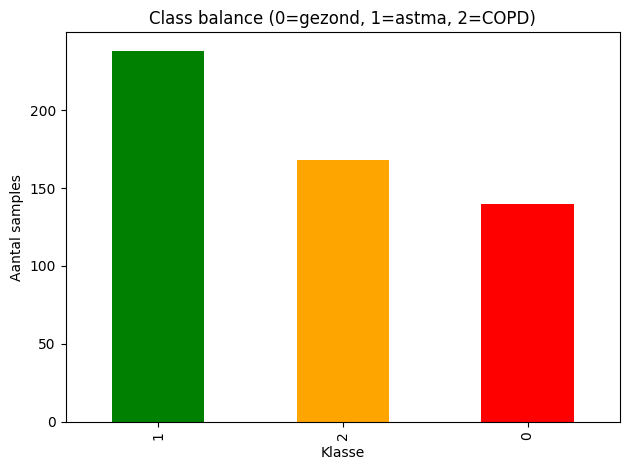

In [16]:
import matplotlib.pyplot as plt
df_train['disease'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Class balance (0=gezond, 1=astma, 2=COPD)')
plt.xlabel('Klasse')
plt.ylabel('Aantal samples')
plt.tight_layout()
plt.show()

## 1.3 Bekijk audio bestanden

In [23]:
import librosa
import os

sample_id = df_train['candidateID'].iloc[0]

wav_path = f'data/sounds/sounds/{sample_id}/cough.wav'

y, sr = librosa.load(wav_path, sr=None)
print(f"Sample rate: {sr} Hz")
print(f"Duur: {len(y)/sr:.2f} seconden")
print(f"Aantal samples: {len(y)}")

print("\n=== DUUR VAN EERSTE 5 BESTANDEN ===")
for cid in df_train['candidateID'].head(5):
    path = f'data/sounds/sounds/{cid}/cough.wav'
    y, sr = librosa.load(path, sr=None)
    print(f"{cid}: {len(y)/sr:.2f}s  (sr={sr})")

Sample rate: 48000 Hz
Duur: 10.07 seconden
Aantal samples: 483328

=== DUUR VAN EERSTE 5 BESTANDEN ===
b87ea0dd760fa: 10.07s  (sr=48000)
b734834dec6d1: 18.43s  (sr=48000)
e000a41725f53: 12.63s  (sr=48000)
253ba780a0398: 9.13s  (sr=48000)
6663cd023ff3d: 9.98s  (sr=48000)


Sample rate : 48.000 Hz (gaan we veranderen naar 16.000 hz)
Duur: varieert sterk. (gaan we truncaten/padden naar een vaste lengte)

## 1.4 Feature check (check voor NaN's, strings etc)

In [26]:
df_train.isnull().sum()

candidateID              0
age                      0
gender                   0
tbContactHistory         0
wheezingHistory          0
phlegmCough              0
familyAsthmaHistory      0
feverHistory             0
coldPresent            148
packYears                0
disease                  0
dtype: int64

coldPresent (of dat ze verkouden waren of niet tijdens checkup) : 148 NaN's

In [27]:
df_train.dtypes

candidateID                str
age                      int64
gender                   int64
tbContactHistory       float64
wheezingHistory        float64
phlegmCough            float64
familyAsthmaHistory    float64
feverHistory             int64
coldPresent            float64
packYears                int64
disease                  int64
dtype: object

Perfect, alles staat in numerieke waarde. candidateID laten we als string, dit wordt gewoon gebruikt om de .wav te linken.